# Credit Card Fraud Detection using Machine Learning

## Oasis Infobyte Data Analytics Internship

### Objective
Build a machine learning pipeline to detect fraudulent credit card transactions from a highly imbalanced dataset. The project explores class imbalance, applies SMOTE for oversampling, trains classification models, and evaluates them using appropriate metrics such as Precision, Recall, F1-Score, and ROC-AUC.

### Dataset
- Credit Card Fraud Detection Dataset (Kaggle)
- Total Transactions: 284,807
- Fraudulent Transactions: 492
- Features: 30 numerical features + Class label

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Imbalanced-learn (SMOTE)

### Author
Deborah K.

In [1]:
# ============================================================
# Credit Card Fraud Detection
# Oasis Infobyte Internship
# ============================================================

import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Plot Styling
plt.style.use("ggplot")
sns.set_style("whitegrid")

# High-quality figures
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 120

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load dataset
df = pd.read_csv("../data/creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 284807
Columns: 31


In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
missing = df.isnull().sum()

missing

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
print("Total Missing Values:", missing.sum())

Total Missing Values: 0


## Class Imbalance Analysis

Fraud detection datasets are typically highly imbalanced because fraudulent transactions are rare compared to legitimate ones. Before training a machine learning model, it is important to understand the distribution of the target classes. This analysis helps explain why techniques such as SMOTE are needed and why evaluation metrics beyond accuracy are important.

In [10]:
# Count each class
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
# Calculate percentages
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_percent)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [12]:
fraud_count = class_counts[1]
normal_count = class_counts[0]
total = len(df)

fraud_percentage = (fraud_count / total) * 100

print(f"Total Transactions : {total:,}")
print(f"Legitimate Transactions : {normal_count:,}")
print(f"Fraudulent Transactions : {fraud_count:,}")
print(f"Fraud Percentage : {fraud_percentage:.4f}%")

Total Transactions : 284,807
Legitimate Transactions : 284,315
Fraudulent Transactions : 492
Fraud Percentage : 0.1727%


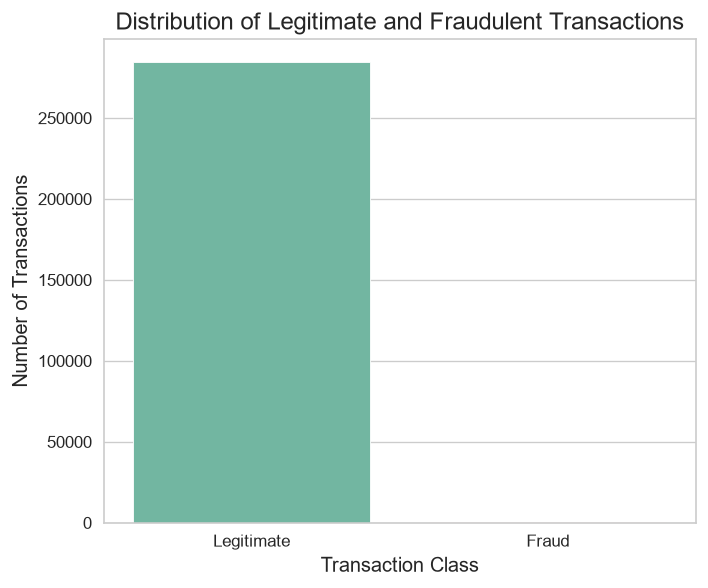

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Class",
    palette="Set2"
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()

plt.savefig(
    "../images/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The dataset is extremely imbalanced. Approximately **99.83%** of the transactions are legitimate, while only **0.17%** are fraudulent. This imbalance means that a machine learning model trained without any balancing technique may become biased toward predicting the majority class. Therefore, techniques such as SMOTE and evaluation metrics like Precision, Recall, F1-Score, and ROC-AUC are more appropriate than relying solely on accuracy.

## Exploratory Data Analysis (EDA)

This section explores patterns in the transaction data to understand how fraudulent and legitimate transactions differ.

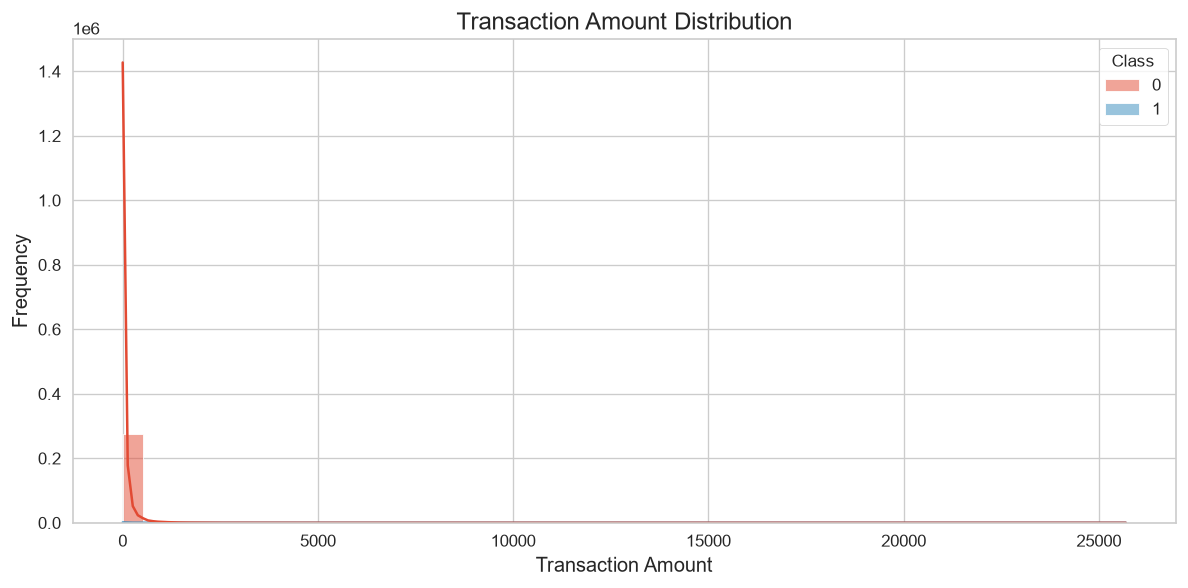

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../images/transaction_amount_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

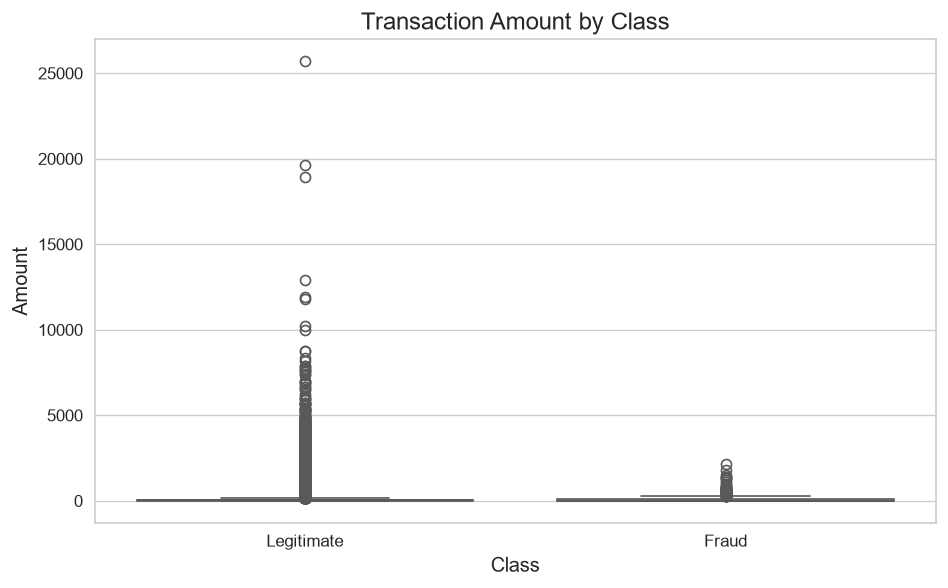

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount",
    palette="Set2"
)

plt.xticks([0,1],["Legitimate","Fraud"])
plt.title("Transaction Amount by Class")

plt.tight_layout()

plt.savefig(
    "../images/fraud_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Most transactions involve relatively small amounts. Fraudulent transactions also occur across a range of amounts, although the distribution differs from legitimate transactions. The presence of outliers suggests that transaction amount alone is not sufficient for detecting fraud.

In [16]:
df["Hour"] = (df["Time"] / 3600) % 24

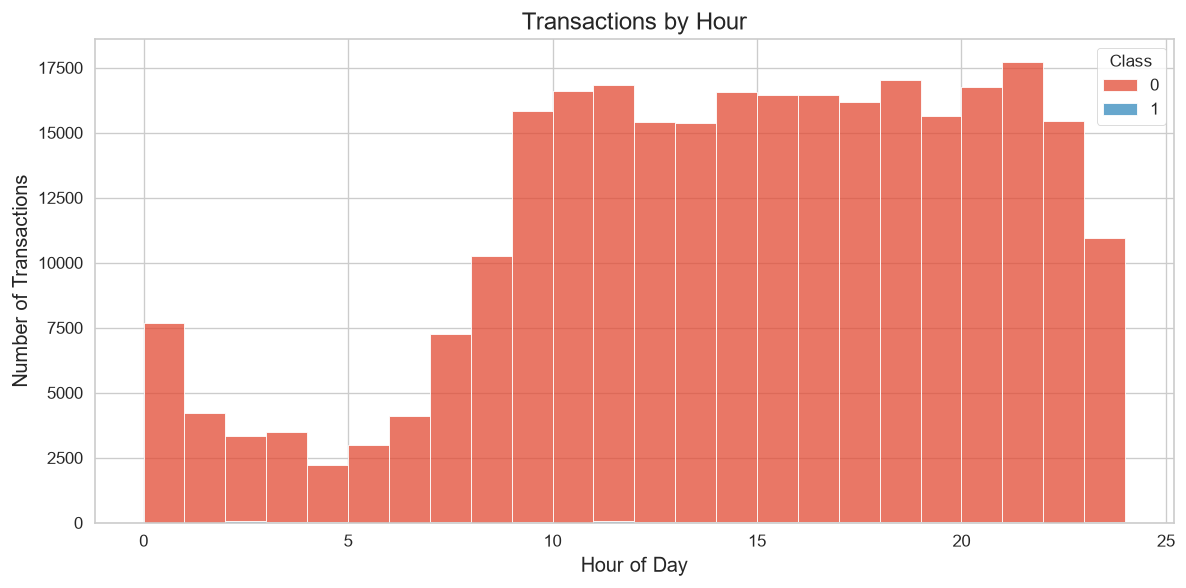

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Hour",
    hue="Class",
    bins=24,
    multiple="stack"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    "../images/transactions_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Fraudulent transactions occur throughout the day rather than at a single specific hour. Time alone does not clearly separate fraudulent from legitimate transactions, but it may still contribute useful information when combined with other features.

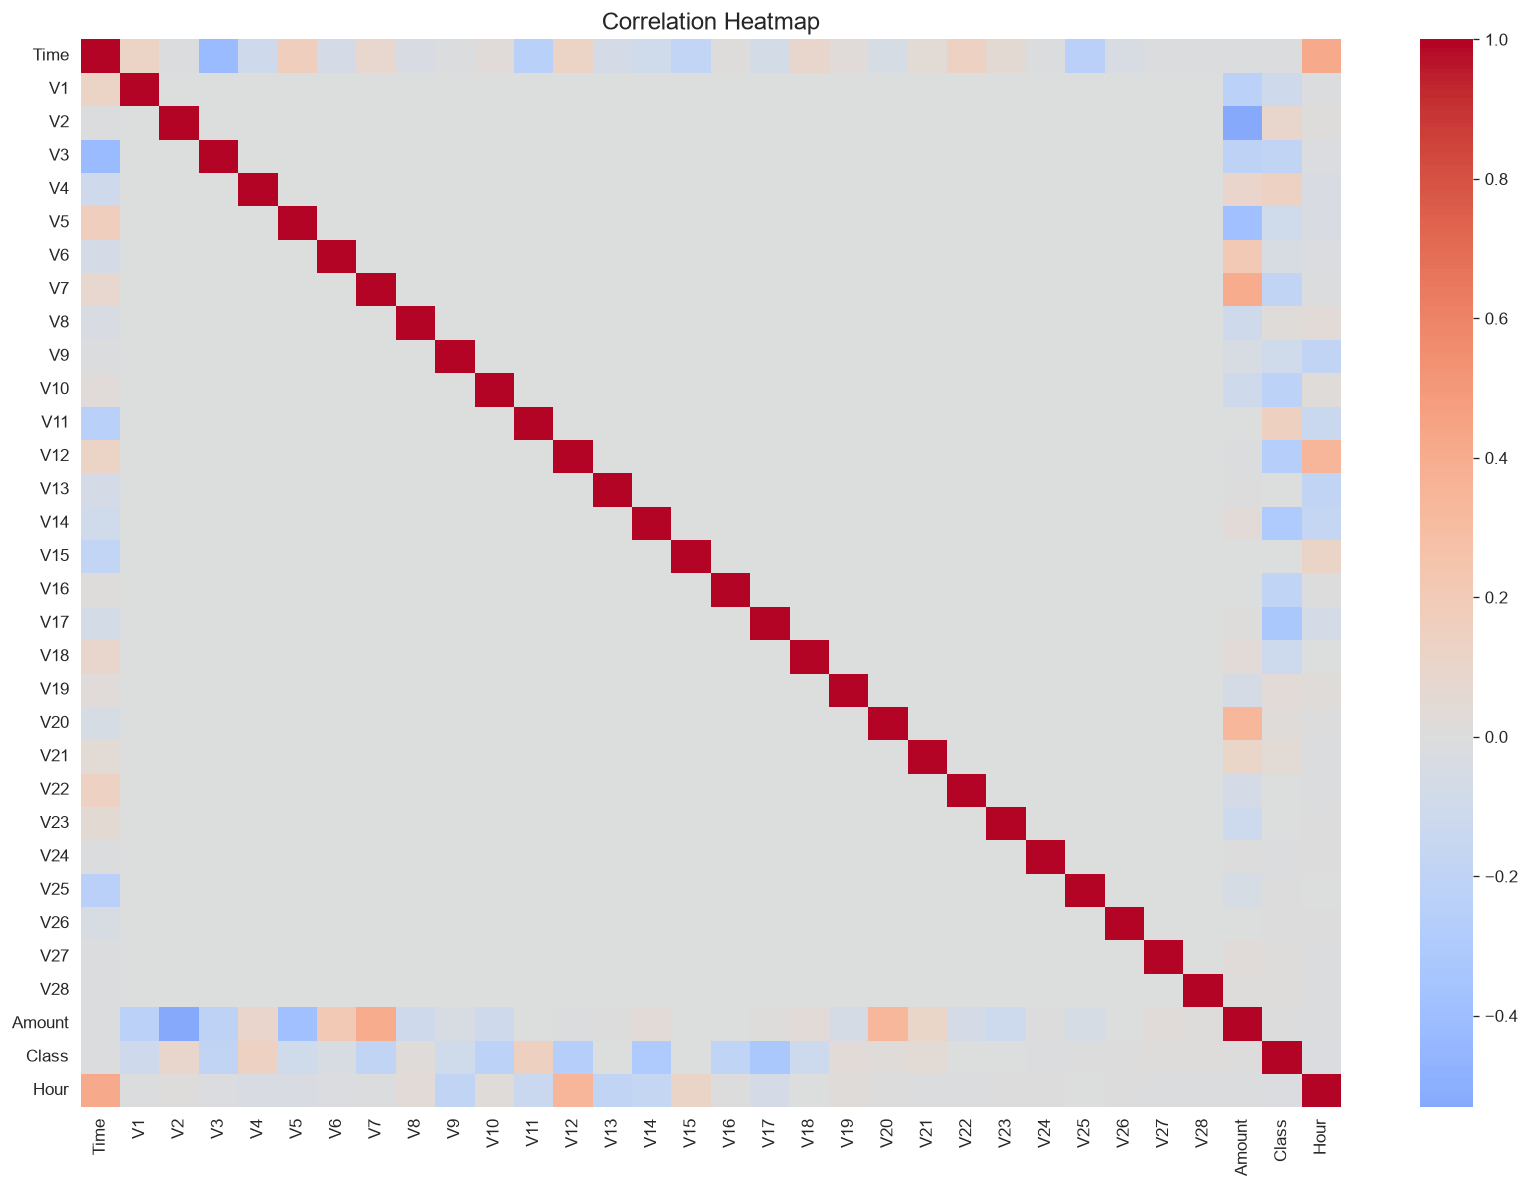

In [18]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Most features exhibit weak correlations because the variables have been transformed using Principal Component Analysis (PCA). This transformation reduces multicollinearity while preserving information useful for fraud detection.

## Why Accuracy is Misleading

The dataset is highly imbalanced, with fraudulent transactions representing only about **0.17%** of all records. A model that predicts every transaction as legitimate would achieve an accuracy of approximately **99.83%**, yet it would fail to detect any fraud.

For this reason, accuracy alone is not an appropriate evaluation metric. Instead, this project focuses on Precision, Recall, F1-Score, and ROC-AUC, which provide a better assessment of fraud detection performance on imbalanced datasets.

## Data Preparation

Before training the models, the dataset is divided into input features (`X`) and the target variable (`y`). The target variable (`Class`) indicates whether a transaction is legitimate (`0`) or fraudulent (`1`).

In [19]:
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (284807, 31)
Target Shape: (284807,)


## Train-Test Split

The dataset is split into training and testing sets using stratified sampling. Stratification preserves the original class distribution in both sets, ensuring that fraudulent transactions are represented in both training and testing data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (227845, 31)
Testing Set  : (56962, 31)


In [22]:
print("Training Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Training Class Distribution
Class
0    227451
1       394
Name: count, dtype: int64

Testing Class Distribution
Class
0    56864
1       98
Name: count, dtype: int64


## Handling Class Imbalance with SMOTE

Since fraudulent transactions are extremely rare, the Synthetic Minority Oversampling Technique (SMOTE) is applied to the training data. SMOTE generates synthetic examples of the minority class, allowing the model to learn fraud patterns more effectively without altering the test set.

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Distribution")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Original Training Distribution
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE
Class
0    227451
1    227451
Name: count, dtype: int64


## Logistic Regression Model

Logistic Regression serves as a baseline classification model for fraud detection. It estimates the probability that a transaction belongs to the fraudulent class.

In [24]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [25]:
log_predictions = log_model.predict(X_test)

log_probabilities = log_model.predict_proba(X_test)[:,1]

## Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It is capable of capturing complex, non-linear relationships within the data and often performs well on fraud detection tasks.

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [27]:
rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:,1]

In [28]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(classification_report(y_test, log_predictions))

with open("../outputs/logistic_report.txt", "w") as f:
    f.write(classification_report(y_test, log_predictions))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [29]:
log_precision = precision_score(y_test, log_predictions)
log_recall = recall_score(y_test, log_predictions)
log_f1 = f1_score(y_test, log_predictions)
log_auc = roc_auc_score(y_test, log_probabilities)

print(f"Precision : {log_precision:.4f}")
print(f"Recall    : {log_recall:.4f}")
print(f"F1 Score  : {log_f1:.4f}")
print(f"ROC-AUC   : {log_auc:.4f}")

Precision : 0.1210
Recall    : 0.8980
F1 Score  : 0.2133
ROC-AUC   : 0.9723


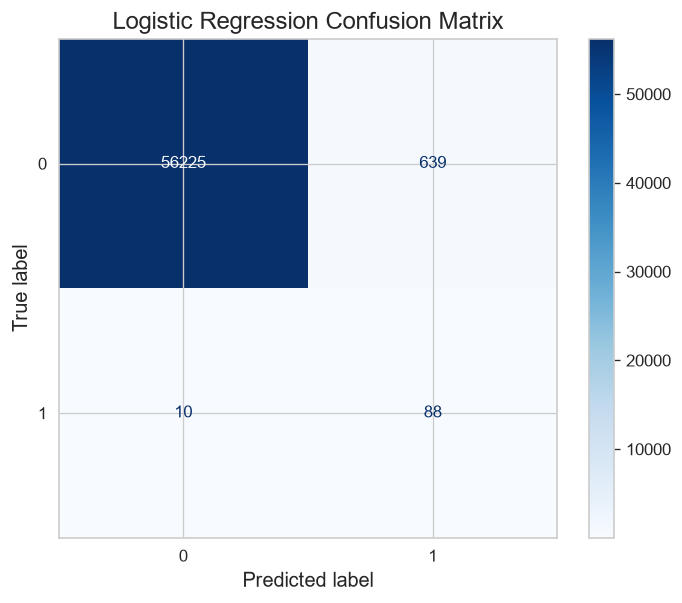

In [30]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    cmap="Blues",
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(classification_report(y_test, rf_predictions))

with open("../outputs/random_forest_report.txt", "w") as f:
    f.write(classification_report(y_test, rf_predictions))

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.85      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [32]:
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_auc:.4f}")

Precision : 0.8469
Recall    : 0.8469
F1 Score  : 0.8469
ROC-AUC   : 0.9693


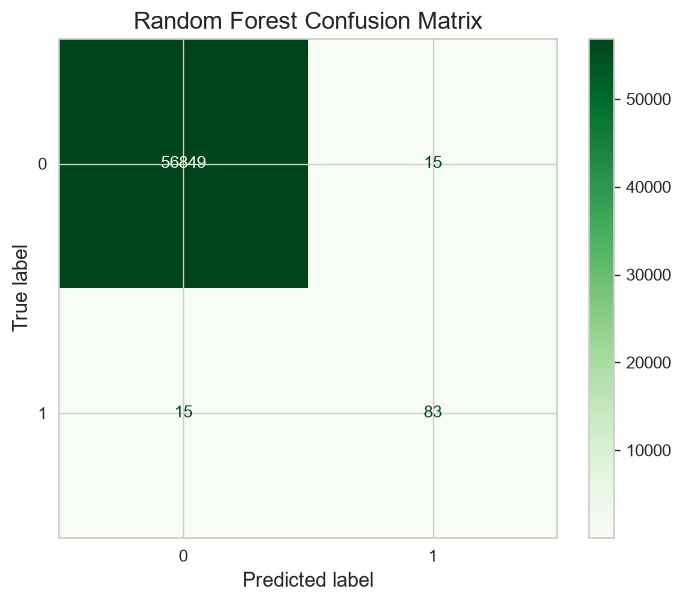

In [33]:
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap="Greens",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

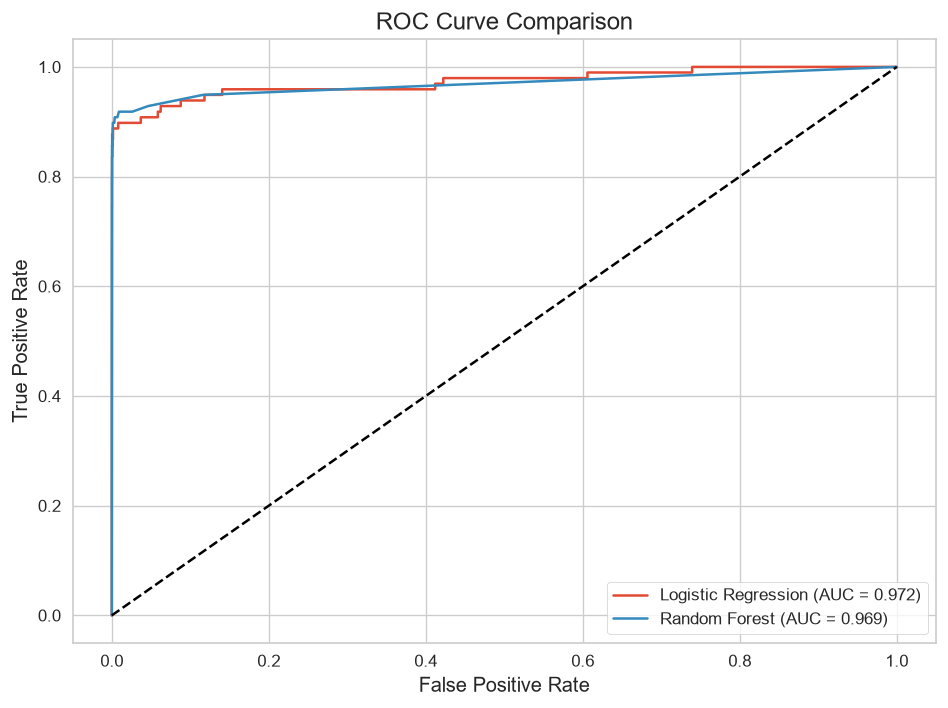

In [34]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_probabilities)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probabilities)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {log_auc:.3f})")

plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

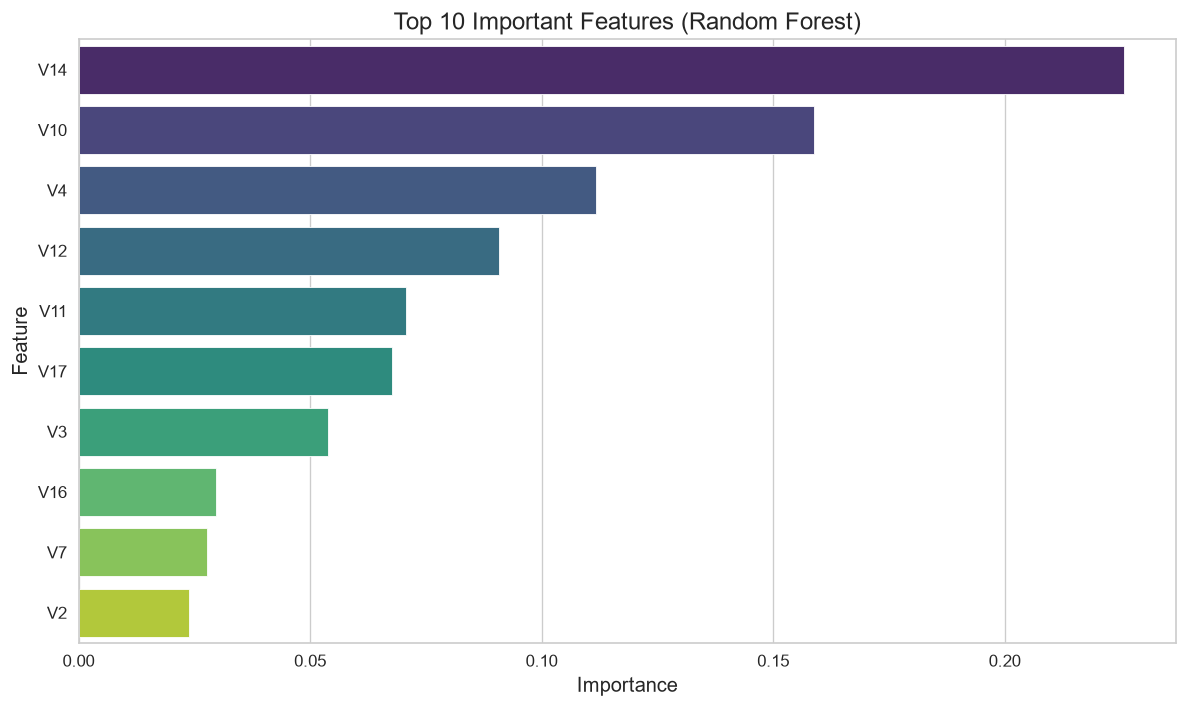

In [35]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.head(10).values,
    y=importance.head(10).index,
    palette="viridis"
)

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

results.sort_values("ROC-AUC", ascending=False)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.121045,0.897959,0.213333,0.972338
1,Random Forest,0.846939,0.846939,0.846939,0.969322


In [37]:
# Display a few predictions
predictions_df = X_test.copy()
predictions_df["Actual"] = y_test.values
predictions_df["Predicted"] = rf_predictions
predictions_df["Fraud Probability"] = rf_probabilities

predictions_df[
    ["Amount", "Actual", "Predicted", "Fraud Probability"]
].head(10)

,Amount,Actual,Predicted,Fraud Probability
263020,23.00,0,0,0.00
11378,11.85,0,0,0.00
147283,76.07,0,0,0.04
219439,0.99,0,0,0.00
36939,1.50,0,0,0.00
243438,8.99,0,0,0.00
259448,52.00,0,0,0.00
43800,3.59,0,0,0.00
66742,27.92,0,0,0.00
66499,95.25,0,0,0.00


In [38]:
predictions_df[predictions_df["Actual"] == 1].head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Hour,Actual,Predicted,Fraud Probability
77348,57007.0,-1.271244,2.462675,-2.851395,2.324480,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,...,-0.523582,0.224228,0.756335,0.632800,0.250187,0.01,15.835278,1,1,1.00
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,18.946389,1,1,1.00
119781,75581.0,-2.866364,2.346949,-4.053307,3.983359,-3.463186,-1.280953,-4.474764,1.216655,-2.309829,...,0.282030,-0.506901,-0.371741,0.615257,0.803163,124.53,20.994722,1,1,0.94
48094,43494.0,-1.278138,0.716242,-1.143279,0.217805,-1.293890,-1.168952,-2.564182,0.204532,-1.611155,...,-0.126644,-0.661908,-0.349793,0.454851,0.137843,24.90,12.081667,1,1,0.76
42958,41313.0,-13.897206,6.344280,-14.281666,5.581009,-12.887133,-3.146176,-15.450467,9.060281,-5.486121,...,0.763508,0.075456,-0.453840,-1.508968,-0.686836,9.99,11.475833,1,1,0.91
52584,45541.0,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,...,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,1.00,12.650278,1,1,1.00
204064,135095.0,0.232512,0.938944,-4.647780,3.079844,-1.902655,-1.041408,-1.020407,0.547069,-1.105990,...,0.901260,-0.452093,0.192959,0.180859,-0.029315,345.00,13.526389,1,1,0.94
151519,95628.0,-17.518909,12.572118,-19.038538,11.190895,-13.554721,-0.411924,-23.189397,-5.301412,-8.630390,...,0.334418,-0.720128,-0.232603,-3.021992,-0.478158,1.63,2.563333,1,1,1.00
203324,134766.0,-0.079653,3.222010,-3.724201,6.037345,0.583395,-0.691346,-1.799885,-2.627781,-4.001338,...,-0.287467,0.808889,0.823962,0.668497,0.595610,1.00,13.435000,1,1,0.96
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,23.390000,1,1,1.00


In [39]:
predictions_df[
    (predictions_df["Actual"] == 1) &
    (predictions_df["Predicted"] == 1)
].head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Hour,Actual,Predicted,Fraud Probability
77348,57007.0,-1.271244,2.462675,-2.851395,2.324480,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,...,-0.523582,0.224228,0.756335,0.632800,0.250187,0.01,15.835278,1,1,1.00
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,18.946389,1,1,1.00
119781,75581.0,-2.866364,2.346949,-4.053307,3.983359,-3.463186,-1.280953,-4.474764,1.216655,-2.309829,...,0.282030,-0.506901,-0.371741,0.615257,0.803163,124.53,20.994722,1,1,0.94
48094,43494.0,-1.278138,0.716242,-1.143279,0.217805,-1.293890,-1.168952,-2.564182,0.204532,-1.611155,...,-0.126644,-0.661908,-0.349793,0.454851,0.137843,24.90,12.081667,1,1,0.76
42958,41313.0,-13.897206,6.344280,-14.281666,5.581009,-12.887133,-3.146176,-15.450467,9.060281,-5.486121,...,0.763508,0.075456,-0.453840,-1.508968,-0.686836,9.99,11.475833,1,1,0.91
52584,45541.0,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,...,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,1.00,12.650278,1,1,1.00
204064,135095.0,0.232512,0.938944,-4.647780,3.079844,-1.902655,-1.041408,-1.020407,0.547069,-1.105990,...,0.901260,-0.452093,0.192959,0.180859,-0.029315,345.00,13.526389,1,1,0.94
151519,95628.0,-17.518909,12.572118,-19.038538,11.190895,-13.554721,-0.411924,-23.189397,-5.301412,-8.630390,...,0.334418,-0.720128,-0.232603,-3.021992,-0.478158,1.63,2.563333,1,1,1.00
203324,134766.0,-0.079653,3.222010,-3.724201,6.037345,0.583395,-0.691346,-1.799885,-2.627781,-4.001338,...,-0.287467,0.808889,0.823962,0.668497,0.595610,1.00,13.435000,1,1,0.96
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,23.390000,1,1,1.00


In [40]:
predictions_df[
    (predictions_df["Actual"] == 1) &
    (predictions_df["Predicted"] == 0)
]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Hour,Actual,Predicted,Fraud Probability
70589,53937.0,-2.042608,1.573578,-2.372652,-0.572676,-2.097353,-0.174142,-3.039520,-1.634233,-0.594809,...,-0.600514,0.127547,-0.786072,0.606097,0.171697,261.87,14.982500,1,0,0.49
50537,44532.0,-0.234922,0.355413,1.972183,-1.255593,-0.681387,-0.665732,0.059110,-0.003153,1.122451,...,0.451208,0.188315,-0.531846,0.123185,0.039581,1.00,12.370000,1,0,0.00
157585,110087.0,1.934946,0.650678,-0.286957,3.987828,0.316052,-0.099449,-0.021483,-0.172327,0.508730,...,-0.216597,-0.136692,-0.129954,-0.050077,-0.051082,1.00,6.579722,1,0,0.00
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,0.131111,1,0,0.10
96341,65728.0,1.227614,-0.668974,-0.271785,-0.589440,-0.604795,-0.350285,-0.486365,-0.010809,-0.794944,...,-0.436539,0.494649,-0.283738,-0.001128,0.035075,98.01,18.257778,1,0,0.00
68067,52814.0,-1.101847,-1.632441,0.901067,0.847753,-1.249091,0.654937,1.448868,0.023308,-0.136742,...,-0.029091,-0.300896,0.699175,-0.336072,-0.177587,519.90,14.670556,1,0,0.01
149577,91502.0,0.007379,2.365183,-2.600287,1.111602,3.276441,-1.776141,2.114531,-0.830084,0.900490,...,-0.012944,0.589836,-0.734449,-0.447529,-0.362375,1.00,1.417222,1,0,0.35
219025,141565.0,0.114965,0.766762,-0.494132,0.116772,0.868169,-0.477982,0.438496,0.063073,-0.186207,...,0.600742,-0.604264,0.262938,0.099145,0.010810,4.49,15.323611,1,0,0.00
72757,54846.0,-2.986466,-0.000891,0.605887,0.338338,0.685448,-1.581954,0.504206,-0.233403,0.636768,...,0.355065,0.448552,0.193490,1.214588,-0.013923,1.79,15.235000,1,0,0.00
182992,125612.0,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,...,0.334306,0.147171,0.279556,0.031669,0.035883,3.22,10.892222,1,0,0.23


In [41]:
predictions_df[
    (predictions_df["Actual"] == 0) &
    (predictions_df["Predicted"] == 1)
].head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Hour,Actual,Predicted,Fraud Probability
190263,128759.0,-1.272117,1.827615,-3.810610,0.583759,-0.641242,-1.389043,-1.954054,1.173920,-2.053191,...,0.741676,-0.173234,0.534870,0.183562,0.020316,0.76,11.766389,0,1,0.88
93527,64468.0,1.100390,0.913562,-0.131077,3.051313,0.394822,-0.092167,0.023967,0.098450,-0.343247,...,-0.117883,0.564197,0.107692,0.059026,0.074707,1.00,17.907778,0,1,0.53
14920,26217.0,-17.950631,11.067069,-20.742660,6.075531,-13.389765,-4.532888,-15.188146,12.101062,-4.026880,...,0.102040,1.177477,-0.238730,1.554463,0.547948,1.00,7.282500,0,1,0.91
153457,99129.0,-3.141115,2.014154,-0.610409,5.946659,-1.868534,0.756737,-3.313842,0.227978,-0.937894,...,-0.049373,-0.510364,0.442583,-0.165737,0.682784,45.51,3.535833,0,1,0.84
277737,167826.0,-6.629470,2.872588,-4.817947,0.799106,-2.842538,-1.941351,-4.609837,2.130611,-1.582576,...,0.086836,0.233894,-0.256196,-1.861764,0.261256,1.00,22.618333,0,1,0.61
9643,14446.0,0.526768,0.314305,-0.497534,0.959570,-1.625545,-0.367521,-2.374770,0.556905,0.829738,...,-0.010887,0.146244,1.075946,0.301438,0.171752,39.00,4.012778,0,1,0.71
239473,150125.0,-6.446779,-4.148933,-2.467936,3.579053,1.280263,-1.649037,-4.066319,0.984977,-0.289895,...,0.271926,-1.403307,0.183721,0.151710,0.434945,1.00,17.701389,0,1,0.72
210807,138127.0,1.743948,0.957097,-1.745006,4.076750,1.100496,0.027807,0.205884,0.069681,-1.275351,...,0.474441,-0.117304,-0.122696,-0.002111,0.034234,62.80,14.368611,0,1,0.58
153398,98904.0,-2.690251,1.465266,-0.691844,4.322855,-1.086880,0.063585,-2.966872,-0.059646,-0.090827,...,-0.119366,0.028077,-0.044074,0.005614,0.557189,0.00,3.473333,0,1,0.94
19145,30047.0,-5.345558,5.116875,-9.270055,4.151766,-4.839258,-3.001705,-5.982505,3.892781,-2.587959,...,-0.065900,0.197834,-0.277323,1.242472,0.281893,89.99,8.346389,0,1,0.51


## Recall vs Precision Trade-off

In fraud detection, **Recall** is often the most critical metric because it measures the percentage of fraudulent transactions that are successfully identified. Missing a fraudulent transaction (false negative) can result in significant financial losses.

Precision is also important because a low precision means many legitimate transactions are incorrectly flagged as fraud, creating inconvenience for customers and increasing investigation costs.

A practical fraud detection system aims to maximize Recall while maintaining an acceptable level of Precision.

## Scalability

To handle one million transactions per hour, this model would need to be deployed as a production service rather than executed in a notebook. A scalable solution could include:

- Deploying the trained model using FastAPI or Flask.
- Processing transactions through a streaming platform such as Apache Kafka.
- Running inference on multiple servers with load balancing.
- Monitoring prediction quality and retraining the model periodically to adapt to new fraud patterns.
- Using cloud infrastructure to automatically scale resources based on incoming transaction volume.

These improvements would enable the fraud detection system to process large transaction volumes while maintaining low prediction latency.

## Model Comparison

Two machine learning models were evaluated for fraud detection.

**Logistic Regression**
- Achieved the highest Recall (89.8%), detecting more fraudulent transactions.
- Generated many false positives, resulting in low Precision (12.1%).

**Random Forest**
- Achieved balanced Precision (84.7%) and Recall (84.7%).
- Produced significantly fewer false positives while maintaining strong fraud detection performance.

### Recommendation

For this dataset, Random Forest is the preferred model because it provides a better balance between detecting fraudulent transactions and minimizing false alarms. Although Logistic Regression identified slightly more fraud cases, its low precision would lead to many legitimate transactions being incorrectly flagged, increasing customer inconvenience and operational costs.

## Limitations

- The dataset contains anonymized PCA-transformed features, making feature interpretation difficult.
- SMOTE generates synthetic fraud samples that may not perfectly represent real-world fraud patterns.
- The model was evaluated on historical data and may require periodic retraining to adapt to evolving fraud techniques.
- This notebook is designed for offline analysis rather than real-time deployment.

## Future Improvements

- Experiment with XGBoost and LightGBM.
- Perform hyperparameter tuning using GridSearchCV.
- Optimize the decision threshold for different business objectives.
- Deploy the model using FastAPI for real-time fraud detection.
- Monitor model performance and retrain as fraud patterns evolve.

# Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions using a highly imbalanced dataset.

Key achievements include:

- Performed exploratory data analysis.
- Analyzed severe class imbalance.
- Applied SMOTE to balance the training data.
- Trained Logistic Regression and Random Forest models.
- Evaluated performance using Precision, Recall, F1-Score, and ROC-AUC.
- Identified the most important features influencing fraud detection.
- Discussed deployment considerations for large-scale production systems.

The Random Forest model achieved stronger overall performance and demonstrated its effectiveness for fraud detection on this dataset.